In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Set aesthetic styling for plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (25, 10)


# 1. Fix module imports
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 2. Fix file paths by changing the working directory
# We check if we are currently in the 'notebooks' folder to avoid stepping back too far if you run this cell twice.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir('..')
    
print(f"System path includes: {parent_dir}")
print(f"Current working directory is: {os.getcwd()}")

from src import (
    load_raw,
    get_prices_returns_volume,
    process_universe_etfs,
    load_prices_etf,
    get_returns_etf,
    apply_volume_dampener,
    get_rolling_universe,
    compute_rolling_split,
    calibrate_tradable_universe,
)

System path includes: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA
Current working directory is: /Users/saurabhgupta/Desktop/Courses, Projects and Internships/Algorithmic trading/Statistical arbitrage in US equity markets using PCA


In [11]:
# ---------------------------------------------------------
# 0. SETUP: Extracting the data and calculating residuals
# ---------------------------------------------------------
target_ticker = 'MS' 
target_etf = 'XLF'   
t2e = {target_ticker: [target_etf]}
train_days = 252*5


# 0. Load local raw data (respecting the offline requirement)
raw = load_raw()
prices, returns, volume = get_prices_returns_volume(raw)
prices_etf = load_prices_etf()
returns_etf = get_returns_etf(prices_etf)

# 1. Grab the first 252 valid days for the target stock from the global 'returns' dataframe
stock_returns = returns[target_ticker].dropna().iloc[:train_days]

# 2. Align the ETF returns to match the exact same dates
sector_returns = returns_etf[target_etf].loc[stock_returns.index]
market_returns = returns_etf["SPY"].loc[stock_returns.index]


# 3. Perform OLS Regression: y = alpha + beta * X
y = stock_returns.values
X = np.vstack([np.ones(len(sector_returns)), sector_returns.values, market_returns.values]).T

coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
alpha, beta, beta_market = coeffs[0], coeffs[1], coeffs[2]

# 4. Generate the Residuals
# Residual = Actual Return - Predicted Return
stock_residual = stock_returns - (alpha + beta * sector_returns + beta_market * market_returns)

print(f"Loaded {len(stock_residual)} days of residual data for {target_ticker}.")
print(f"Calculated Sector Beta: {beta:.4f}, Calculated Market Beta: {beta_market:.4f}, Alpha: {alpha:.6f}")

Loading local data from data/raw/raw_data.csv...
Original data shape: (1258, 500)
Raw data loading complete.
Returns calculated. Shape: (1257, 100)
Price data saved to data/raw/prices.csv
Returns data saved to data/raw/returns.csv
Volume data saved to data/raw/volume.csv
Loading local data from data/raw/prices_etf.csv...
Original data shape: (1258, 12)
Raw ETF data loading complete.
Returns calculated. Shape: (1257, 12)
ETF returns data saved to data/raw/returns_etf.csv
Loaded 1257 days of residual data for MS.
Calculated Sector Beta: 1.1413, Calculated Market Beta: 0.0515, Alpha: 0.000258


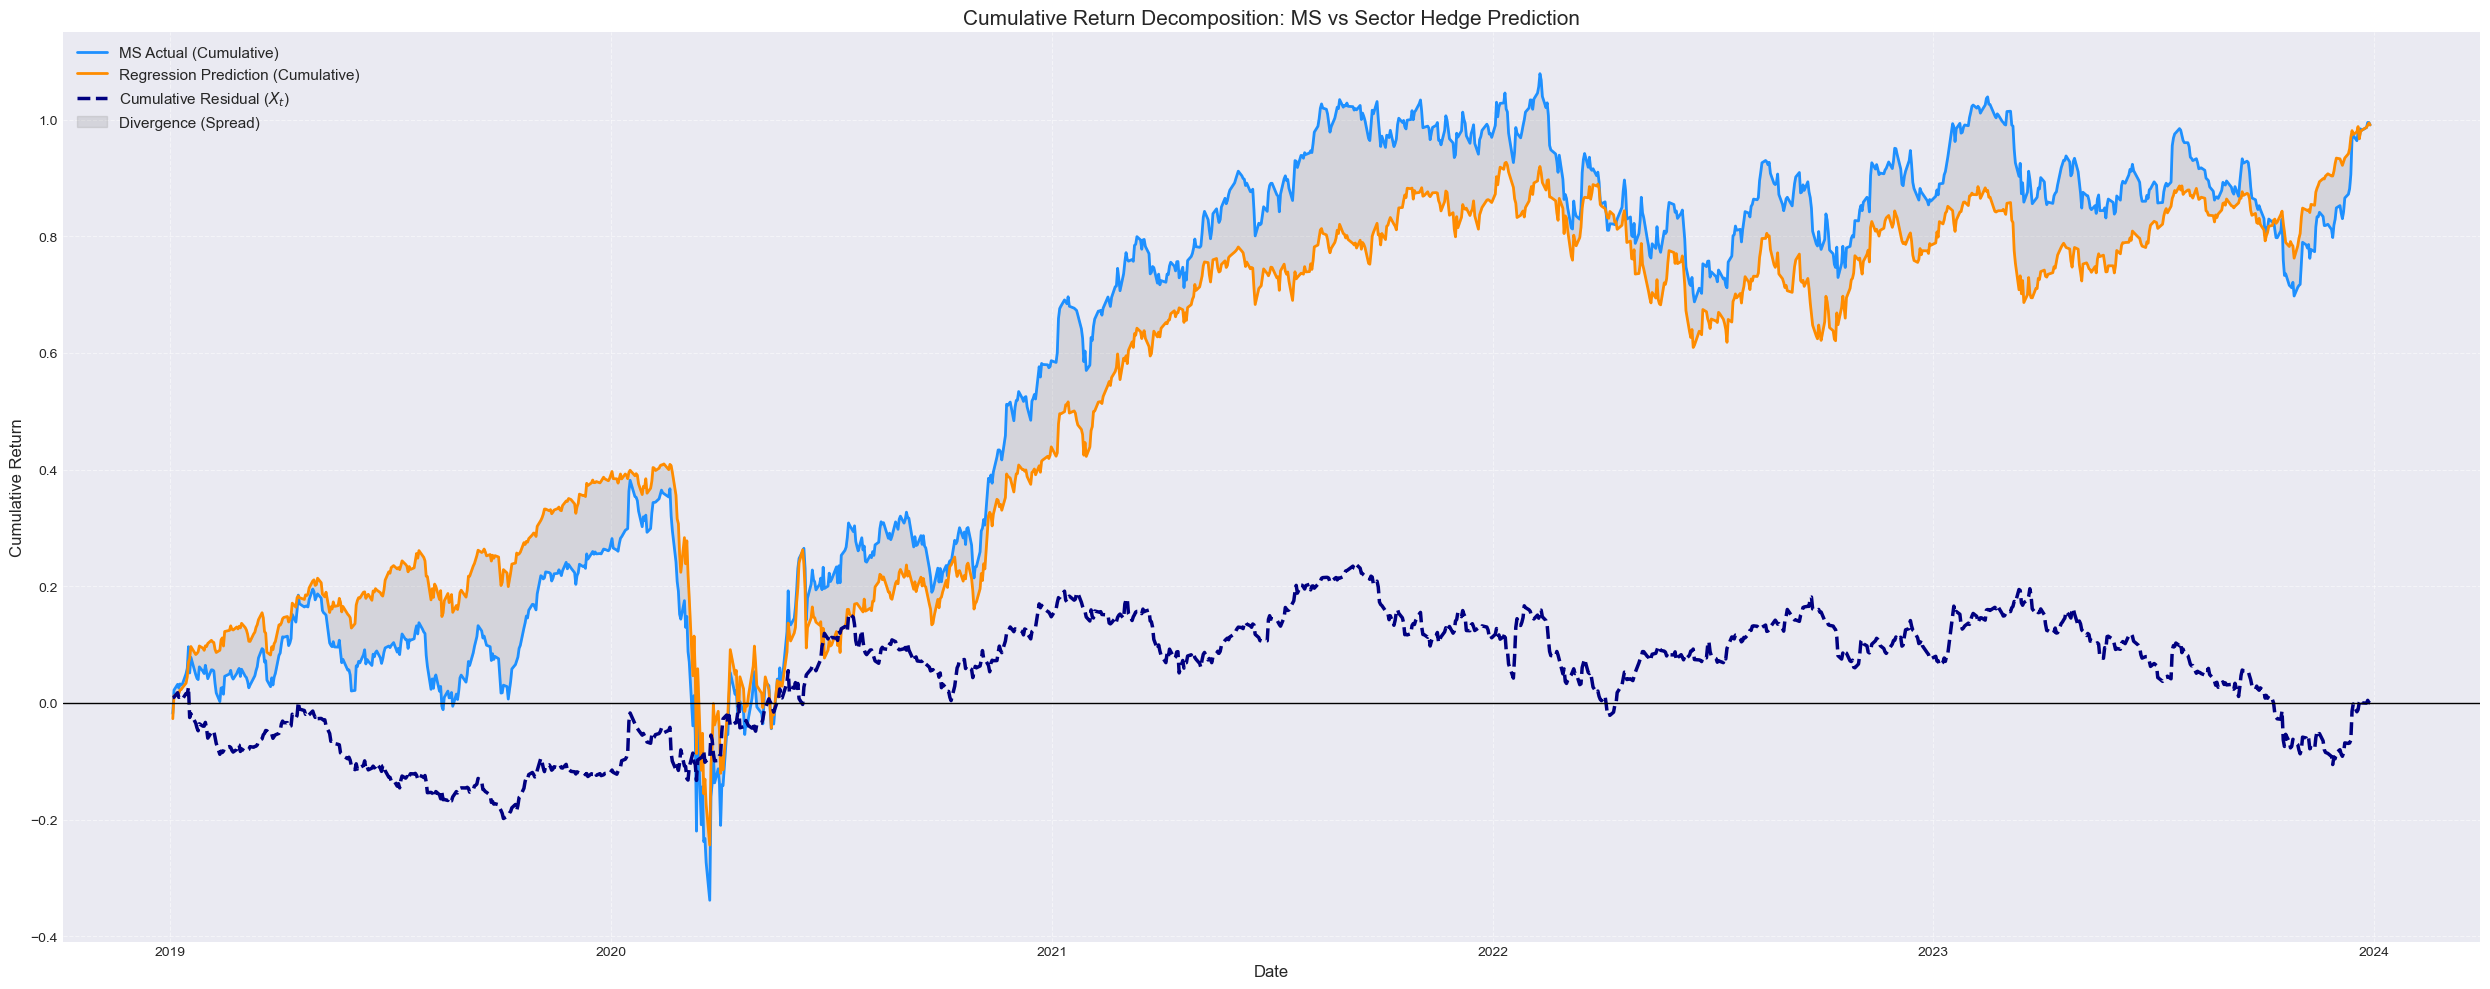

In [27]:
# ---------------------------------------------------------
# VISUALIZATION 0: Return Decomposition & The Spread
# ---------------------------------------------------------
# Calculate cumulative metrics for plotting
cum_stock_returns = stock_returns.cumsum()
predicted_returns = alpha + beta * sector_returns + beta_market * market_returns
cum_predicted_returns = predicted_returns.cumsum()
X_path = stock_residual.cumsum()

plt.figure(figsize=(25, 10))

# Plot the macroscopic trajectories
plt.plot(cum_stock_returns.index, cum_stock_returns, label=f'{target_ticker} Actual (Cumulative)', color='dodgerblue', linewidth=2)
plt.plot(cum_predicted_returns.index, cum_predicted_returns, label=f'Regression Prediction (Cumulative)', color='darkorange', linewidth=2)

# Plot the residual (the spread between the two)
plt.plot(X_path.index, X_path, label='Cumulative Residual ($X_t$)', color='navy', linewidth=2.5, linestyle='--')

# Visually highlight the gap (which is mathematically equal to the navy line)
plt.fill_between(cum_stock_returns.index, cum_stock_returns, cum_predicted_returns, 
                 color='gray', alpha=0.2, label='Divergence (Spread)')

plt.axhline(0, color='black', linewidth=1)
plt.title(f"Cumulative Return Decomposition: {target_ticker} vs Sector Hedge Prediction", fontsize=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Cumulative Return", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

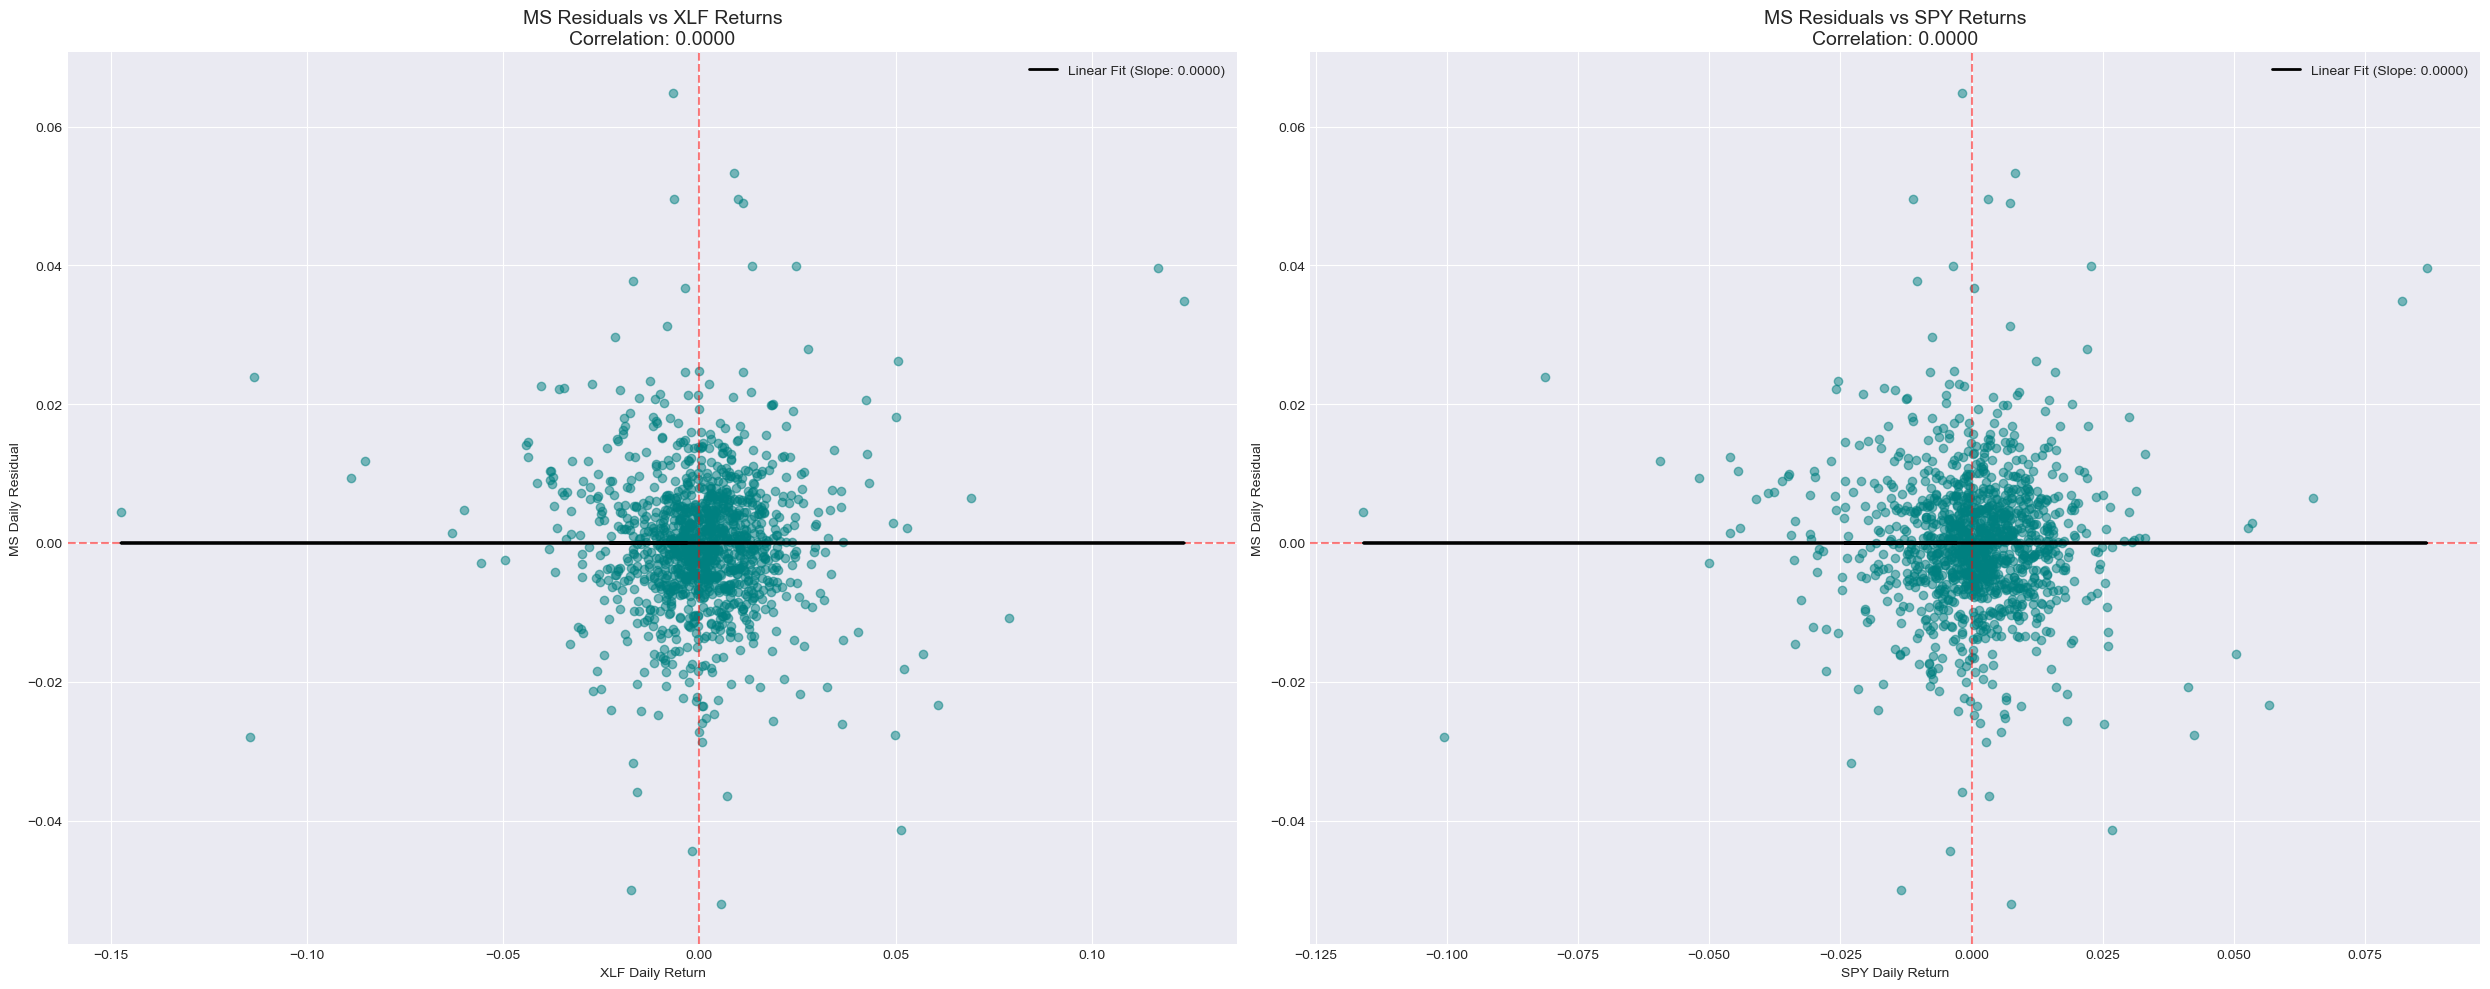

In [13]:
# ---------------------------------------------------------
# PROOF 1A: Orthogonality to the Sector/Market
# ---------------------------------------------------------
sector_correlation = np.corrcoef(stock_residual, sector_returns)[0, 1]
market_correlation = np.corrcoef(stock_residual, market_returns)[0, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10))

ax1.scatter(sector_returns, stock_residual, alpha=0.5, color='teal')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)

# Fit a quick line to show the slope is zero
m1, b1 = np.polyfit(sector_returns, stock_residual, 1)
ax1.plot(sector_returns, m1*sector_returns + b1, color='black', linewidth=2, 
         label=f'Linear Fit (Slope: {m1:.4f})')

# FIXED: Use set_title, set_xlabel, set_ylabel
ax1.set_title(f"{target_ticker} Residuals vs {target_etf} Returns\nCorrelation: {sector_correlation:.4f}", fontsize=14)
ax1.set_xlabel(f"{target_etf} Daily Return")
ax1.set_ylabel(f"{target_ticker} Daily Residual")
ax1.legend()


ax2.scatter(market_returns, stock_residual, alpha=0.5, color='teal')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)

# Fit a quick line to show the slope is zero
m2, b2 = np.polyfit(market_returns, stock_residual, 1)
ax2.plot(market_returns, m2*market_returns + b2, color='black', linewidth=2, 
         label=f'Linear Fit (Slope: {m2:.4f})')

# FIXED: Use set_title, set_xlabel, set_ylabel
ax2.set_title(f"{target_ticker} Residuals vs SPY Returns\nCorrelation: {market_correlation:.4f}", fontsize=14)
ax2.set_xlabel("SPY Daily Return")
ax2.set_ylabel(f"{target_ticker} Daily Residual")
ax2.legend()

# FIXED: Removed ax2.tight_layout() and ax2.show()
plt.tight_layout()
plt.show()

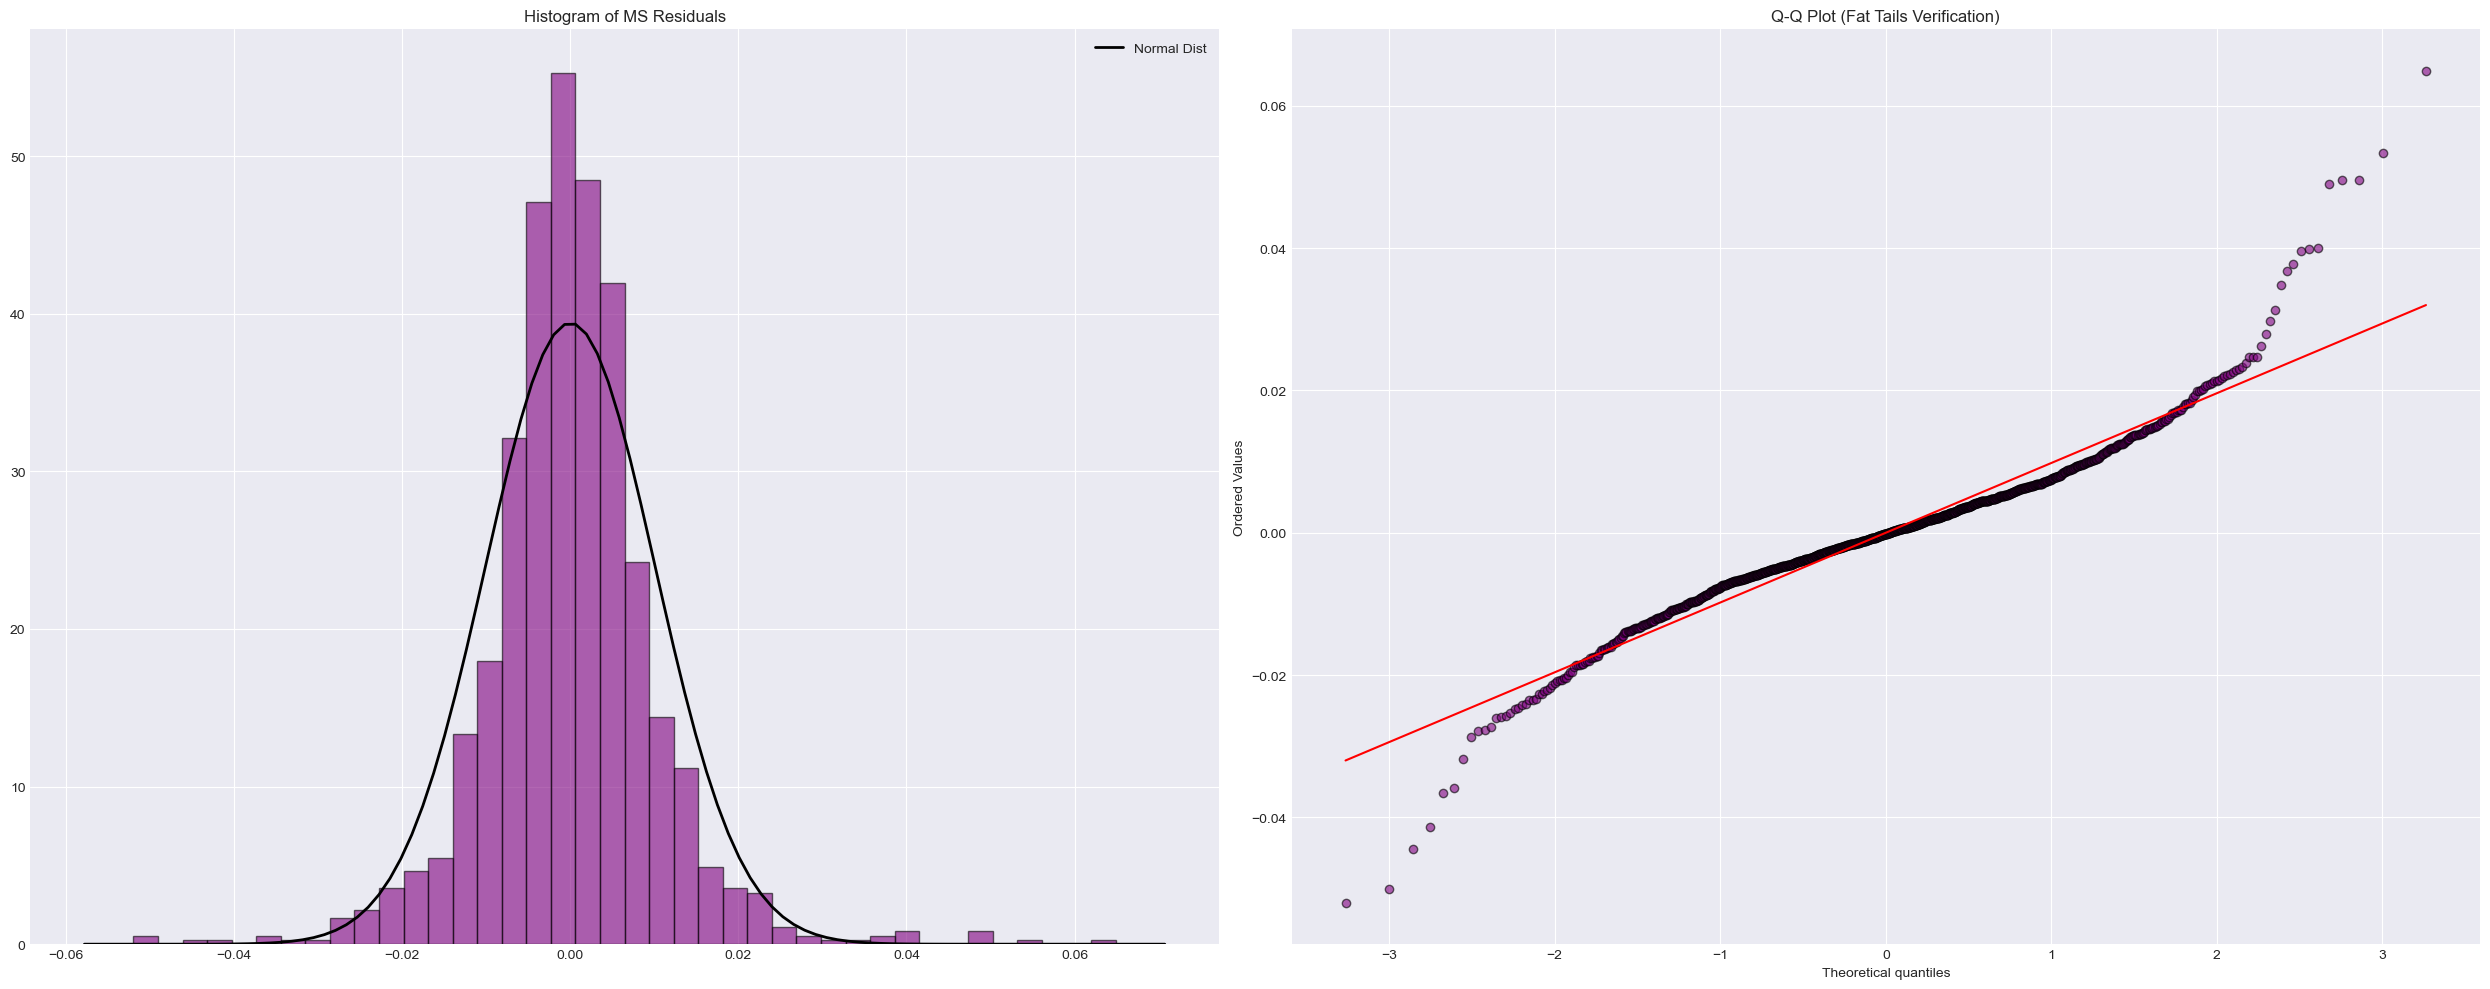

In [14]:
# ---------------------------------------------------------
# 2. Normality & Fat Tails (Q-Q Plot)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10))

# Histogram
ax1.hist(stock_residual, bins=40, density=True, alpha=0.6, color='purple', edgecolor='black')
# Overlay normal distribution
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(stock_residual), np.std(stock_residual))
ax1.plot(x, p, 'k', linewidth=2, label='Normal Dist')
ax1.set_title(f"Histogram of {target_ticker} Residuals")
ax1.legend()

# Q-Q Plot
stats.probplot(stock_residual, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('purple')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[0].set_alpha(0.6)
ax2.set_title(f"Q-Q Plot (Fat Tails Verification)")

plt.tight_layout()
plt.show()

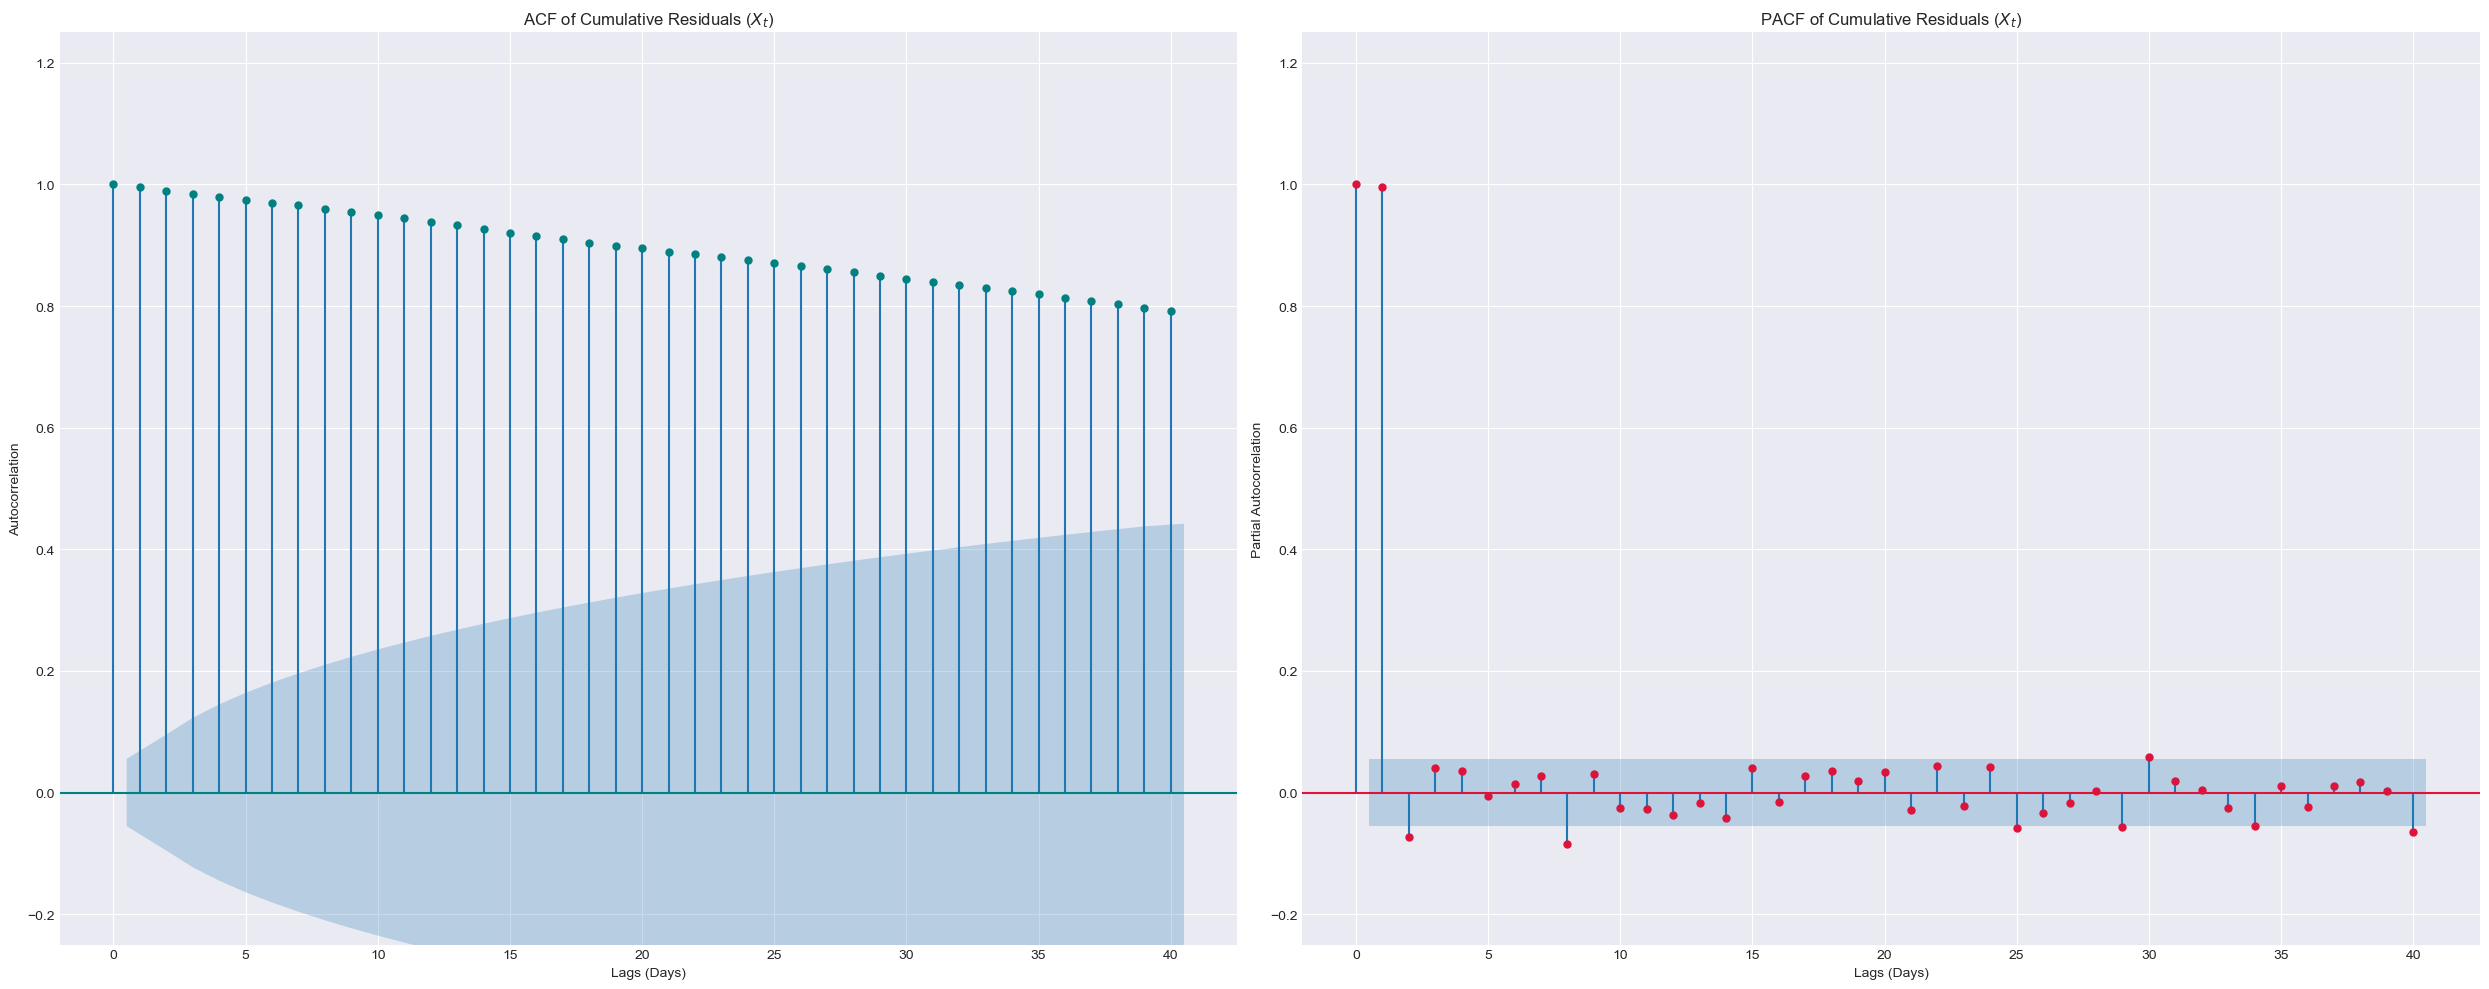

In [21]:
# ---------------------------------------------------------
# 3. ACF/PACF Plots of the Cumulative Residual
# ---------------------------------------------------------
# Calculate the cumulative path
X_path = stock_residual.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10))

# Plot ACF
plot_acf(X_path, ax=ax1, lags=40, alpha=0.05, color='teal')
ax1.set_ylim(-0.25, 1.25)
ax1.set_title(f"ACF of Cumulative Residuals ($X_t$)")
ax1.set_xlabel("Lags (Days)")
ax1.set_ylabel("Autocorrelation")

# Plot PACF
plot_pacf(X_path, ax=ax2, lags=40, alpha=0.05, color='crimson')
ax2.set_ylim(-0.25, 1.25)
ax2.set_title(f"PACF of Cumulative Residuals ($X_t$)")
ax2.set_xlabel("Lags (Days)")
ax2.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

Fitting AR(1) model to the cumulative residuals...


/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/quant_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

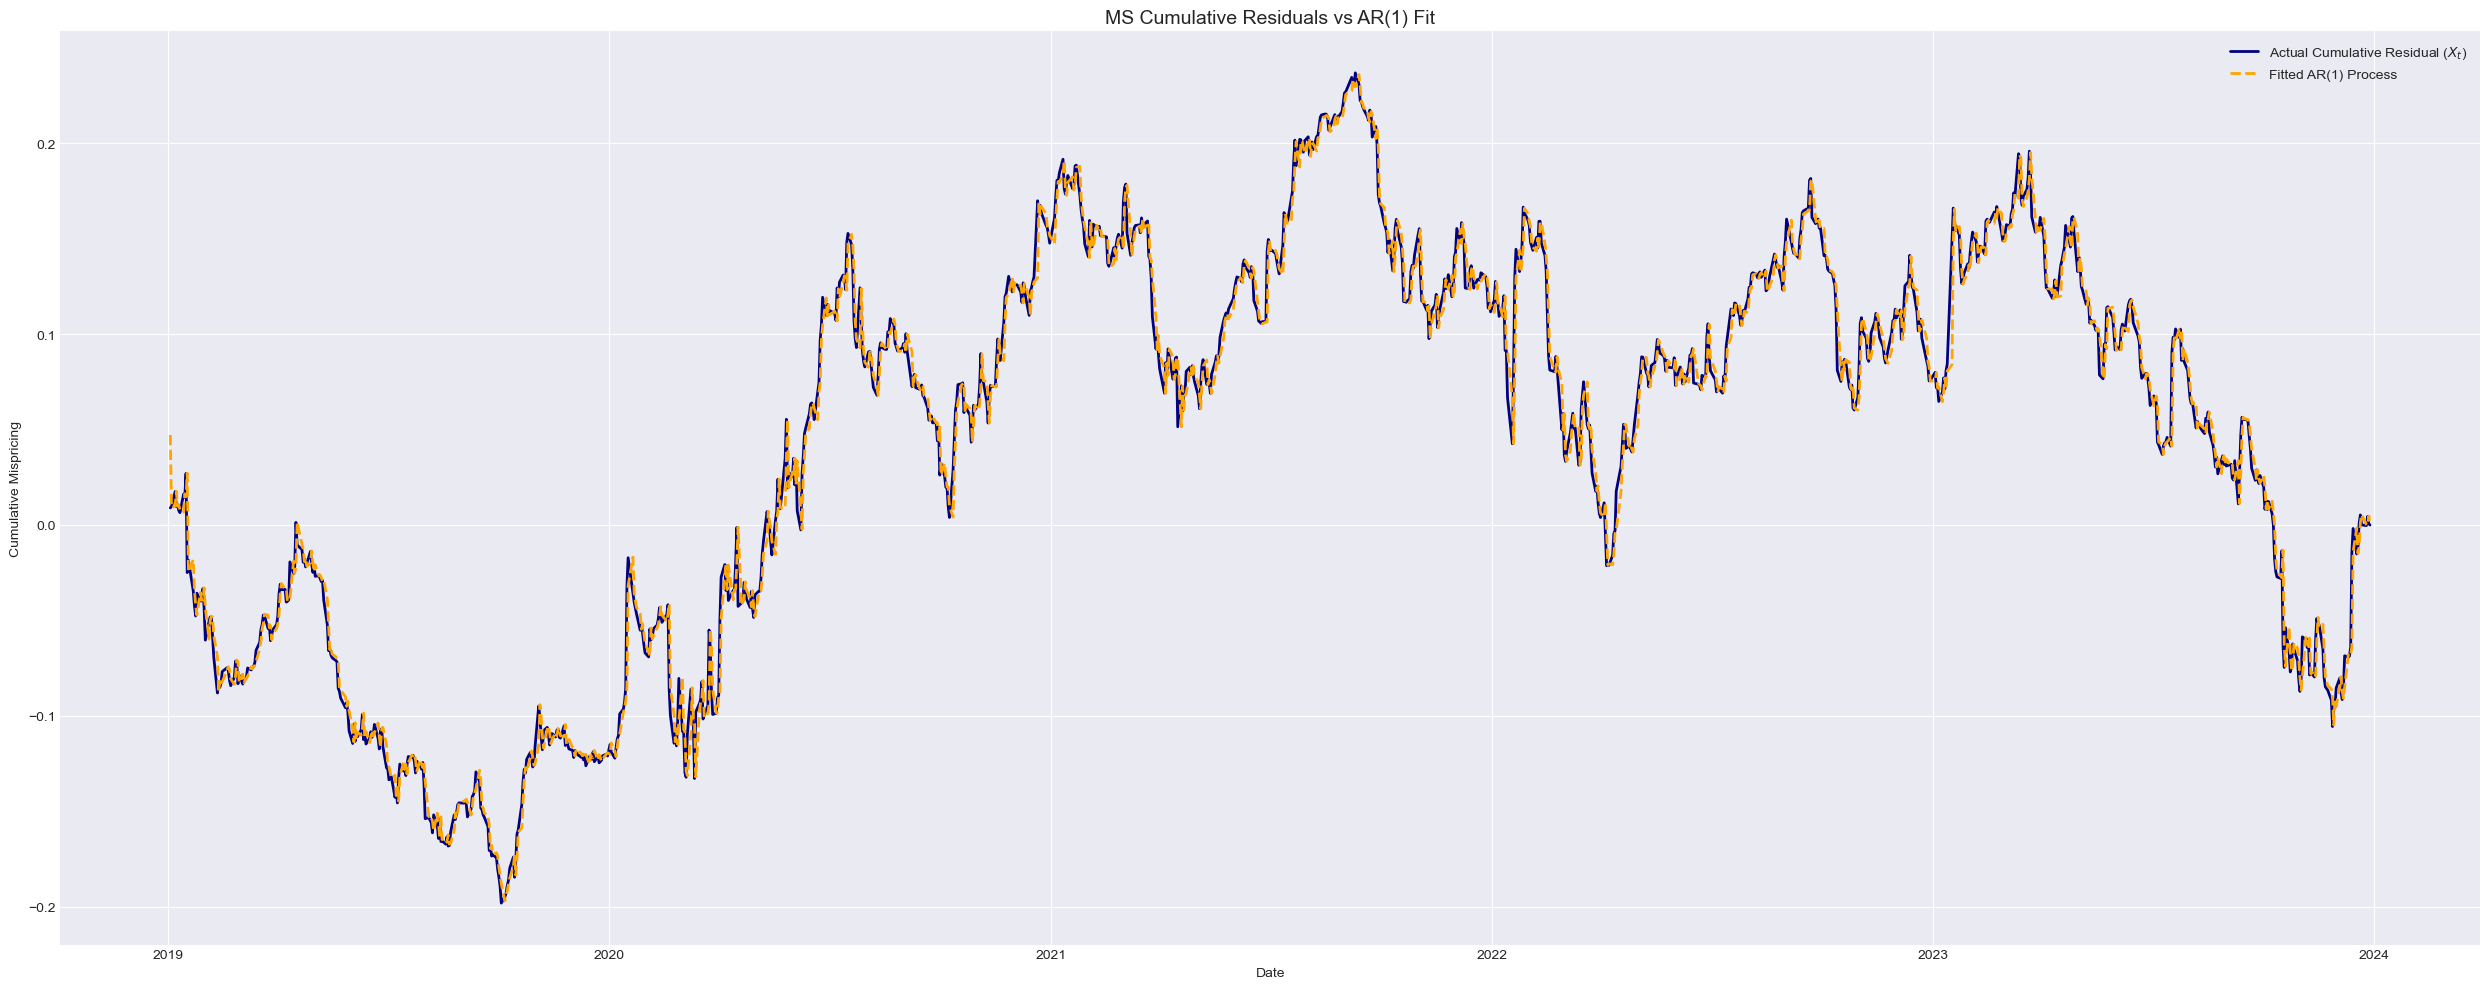

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1257
Model:                 ARIMA(1, 0, 0)   Log Likelihood                3989.236
Date:                Wed, 06 May 2026   AIC                          -7972.471
Time:                        19:02:55   BIC                          -7957.062
Sample:                             0   HQIC                         -7966.680
                               - 1257                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0471      0.059      0.802      0.422      -0.068       0.162
ar.L1          0.9952      0.003    330.734      0.000       0.989       1.001
sigma2         0.0001   2.17e-06     47.138      0.0

In [16]:
# ---------------------------------------------------------
# Set your visually determined AR(p) order here:
# ---------------------------------------------------------
p = 1  

# Fit the AR(p) model
# We use ARIMA(p, d, q) where d=0 and q=0, which makes it a pure AR(p) model
print(f"Fitting AR({p}) model to the cumulative residuals...")
model = ARIMA(X_path, order=(p, 0, 0))
fitted_model = model.fit()

# Extract the fitted values
fitted_X = fitted_model.fittedvalues

# Plot the Actual Path vs the AR(p) Fit
plt.figure(figsize=(25, 10))
plt.plot(X_path.index, X_path, label='Actual Cumulative Residual ($X_t$)', color='navy', linewidth=2)
plt.plot(X_path.index, fitted_X, label=f'Fitted AR({p}) Process', color='orange', linestyle='--', linewidth=2)

plt.title(f"{target_ticker} Cumulative Residuals vs AR({p}) Fit", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Cumulative Mispricing")
plt.legend()
plt.tight_layout()
plt.show()

# Print the econometric summary to verify the significance of the AR coefficients
print(fitted_model.summary())

Executing Walk-Forward Processing (Zero Look-Ahead Bias)...
Processing complete. Generating visualizations.


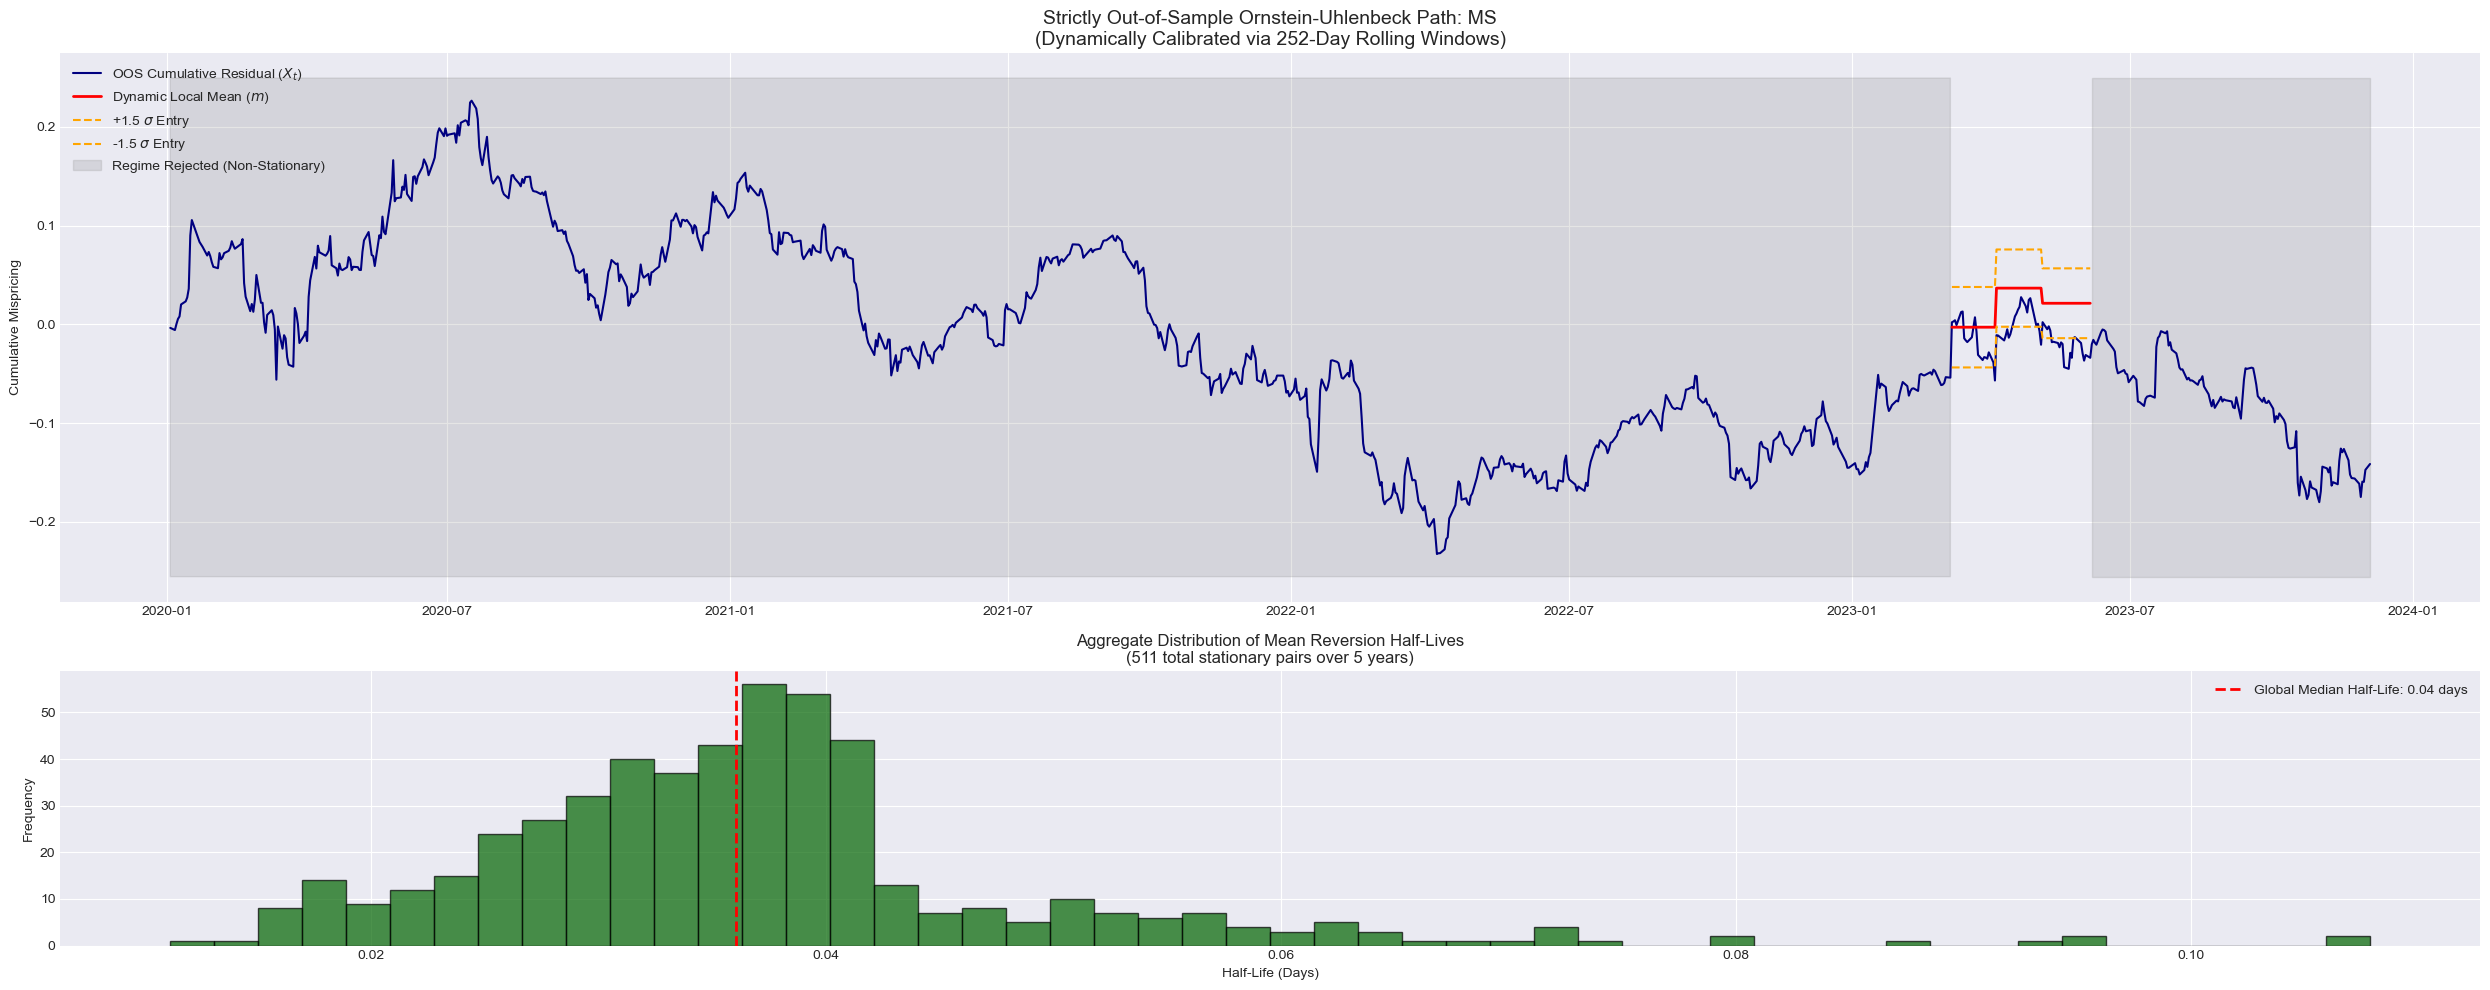

In [17]:
# Storage for the aggregate universe half-lives
all_historical_half_lives = []

# Storage for the Out-of-Sample (Causal) Path
oos_dates = []
oos_X = []
oos_m = []
oos_upper = []
oos_lower = []

train_days = 252
test_days = 21
total_trading_days = len(returns)
current_idx = 0

# Initialize the continuous path state
X_prev = 0.0 

print(f"Executing Walk-Forward Processing (Zero Look-Ahead Bias)...")

while current_idx + train_days + test_days <= total_trading_days:
    
    # 1. Define bounds
    train_start = returns.index[current_idx]
    train_end = returns.index[current_idx + train_days - 1]
    test_start = returns.index[current_idx + train_days]
    test_end = returns.index[current_idx + train_days + test_days - 1]

    # 2. Get universe and apply volume dampener
    train_tickers, train_returns, test_returns_raw = get_rolling_universe(
        returns, train_start, train_end, test_start, test_end
    )

    if len(train_tickers) > 0:
        adjusted_train_returns = apply_volume_dampener(
            train_returns, volume, train_start, train_end, avg_window=60
        )

        # 3. Regress to get residuals (Using ETF baseline for speed)
        residuals_train, residuals_test, betas = compute_rolling_split(
            adjusted_train_returns, test_returns_raw, returns_etf, t2e 
        )

        # 4. Calibrate the OU parameters strictly on the training data
        ou_params = calibrate_tradable_universe(
            residuals_train, adf_p_threshold=0.05
        )

        # 5. Extract Half-lives for the histogram
        for ticker, params in ou_params.items():
            hl = np.inf
            if 'half_life' in params: hl = params['half_life']
            elif 'theta' in params:   hl = np.log(2) / params['theta'] if params['theta'] > 0 else np.inf
            elif 'kappa' in params:   hl = np.log(2) / params['kappa'] if params['kappa'] > 0 else np.inf
            elif 'b' in params:       hl = -np.log(2) / np.log(params['b']) if 0 < params['b'] < 1 else np.inf

            if 0 < hl < 252 * 4:
                all_historical_half_lives.append(hl)

        # 6. Track the Strictly Out-of-Sample Path for the Target Stock
        if target_ticker in residuals_test.columns:
            test_res = residuals_test[target_ticker]
            
            # Did it pass the stationary test in this window?
            if target_ticker in ou_params:
                # Yes: Grab the local mean, sigma, and synchronize the starting point
                m = ou_params[target_ticker]['m']
                sig = ou_params[target_ticker]['sigma_eq']
                X_prev = ou_params[target_ticker]['X_train_end']
                is_stationary = True
            else:
                # No: It is a random walk. We nullify the bands to indicate it is untradable.
                m = np.nan
                sig = np.nan
                is_stationary = False
                
            # Walk forward step-by-step through the 21-day test window
            for date, res in test_res.items():
                if not pd.isna(res):
                    X_current = X_prev + res
                else:
                    X_current = X_prev
                    
                oos_dates.append(date)
                oos_X.append(X_current)
                oos_m.append(m)
                oos_upper.append(m + 1.5 * sig if is_stationary else np.nan)
                oos_lower.append(m - 1.5 * sig if is_stationary else np.nan)
                
                X_prev = X_current

    current_idx += test_days

print("Processing complete. Generating visualizations.")

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10), gridspec_kw={'height_ratios': [2, 1]})

# Plot the continuous Out-of-Sample X path
ax1.plot(oos_dates, oos_X, color='navy', label='OOS Cumulative Residual ($X_t$)', linewidth=1.5)

# Plot the dynamic, shifting step-function bands
ax1.plot(oos_dates, oos_m, color='red', label='Dynamic Local Mean ($m$)', linewidth=2)
ax1.plot(oos_dates, oos_upper, color='orange', linestyle='--', label='+1.5 $\sigma$ Entry', linewidth=1.5)
ax1.plot(oos_dates, oos_lower, color='orange', linestyle='--', label='-1.5 $\sigma$ Entry', linewidth=1.5)

# Fill the gaps where the stock was non-stationary
ax1.fill_between(oos_dates, ax1.get_ylim()[0], ax1.get_ylim()[1], 
                 where=np.isnan(oos_m), color='gray', alpha=0.2, 
                 label='Regime Rejected (Non-Stationary)')

ax1.set_title(f"Strictly Out-of-Sample Ornstein-Uhlenbeck Path: {target_ticker}\n(Dynamically Calibrated via 252-Day Rolling Windows)", fontsize=14)
ax1.set_ylabel("Cumulative Mispricing")
ax1.legend(loc='upper left')


if len(all_historical_half_lives) > 0:
    median_hl = np.median(all_historical_half_lives)
    ax2.hist(all_historical_half_lives, bins=50, color='darkgreen', alpha=0.7, edgecolor='black')
    ax2.axvline(median_hl, color='red', linestyle='dashed', linewidth=2, 
                label=f'Global Median Half-Life: {median_hl:.2f} days')
    ax2.set_title(f"Aggregate Distribution of Mean Reversion Half-Lives\n({len(all_historical_half_lives)} total stationary pairs over 5 years)", fontsize=12)
    ax2.set_xlabel("Half-Life (Days)")
    ax2.set_ylabel("Frequency")
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'No valid half-lives found.', horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

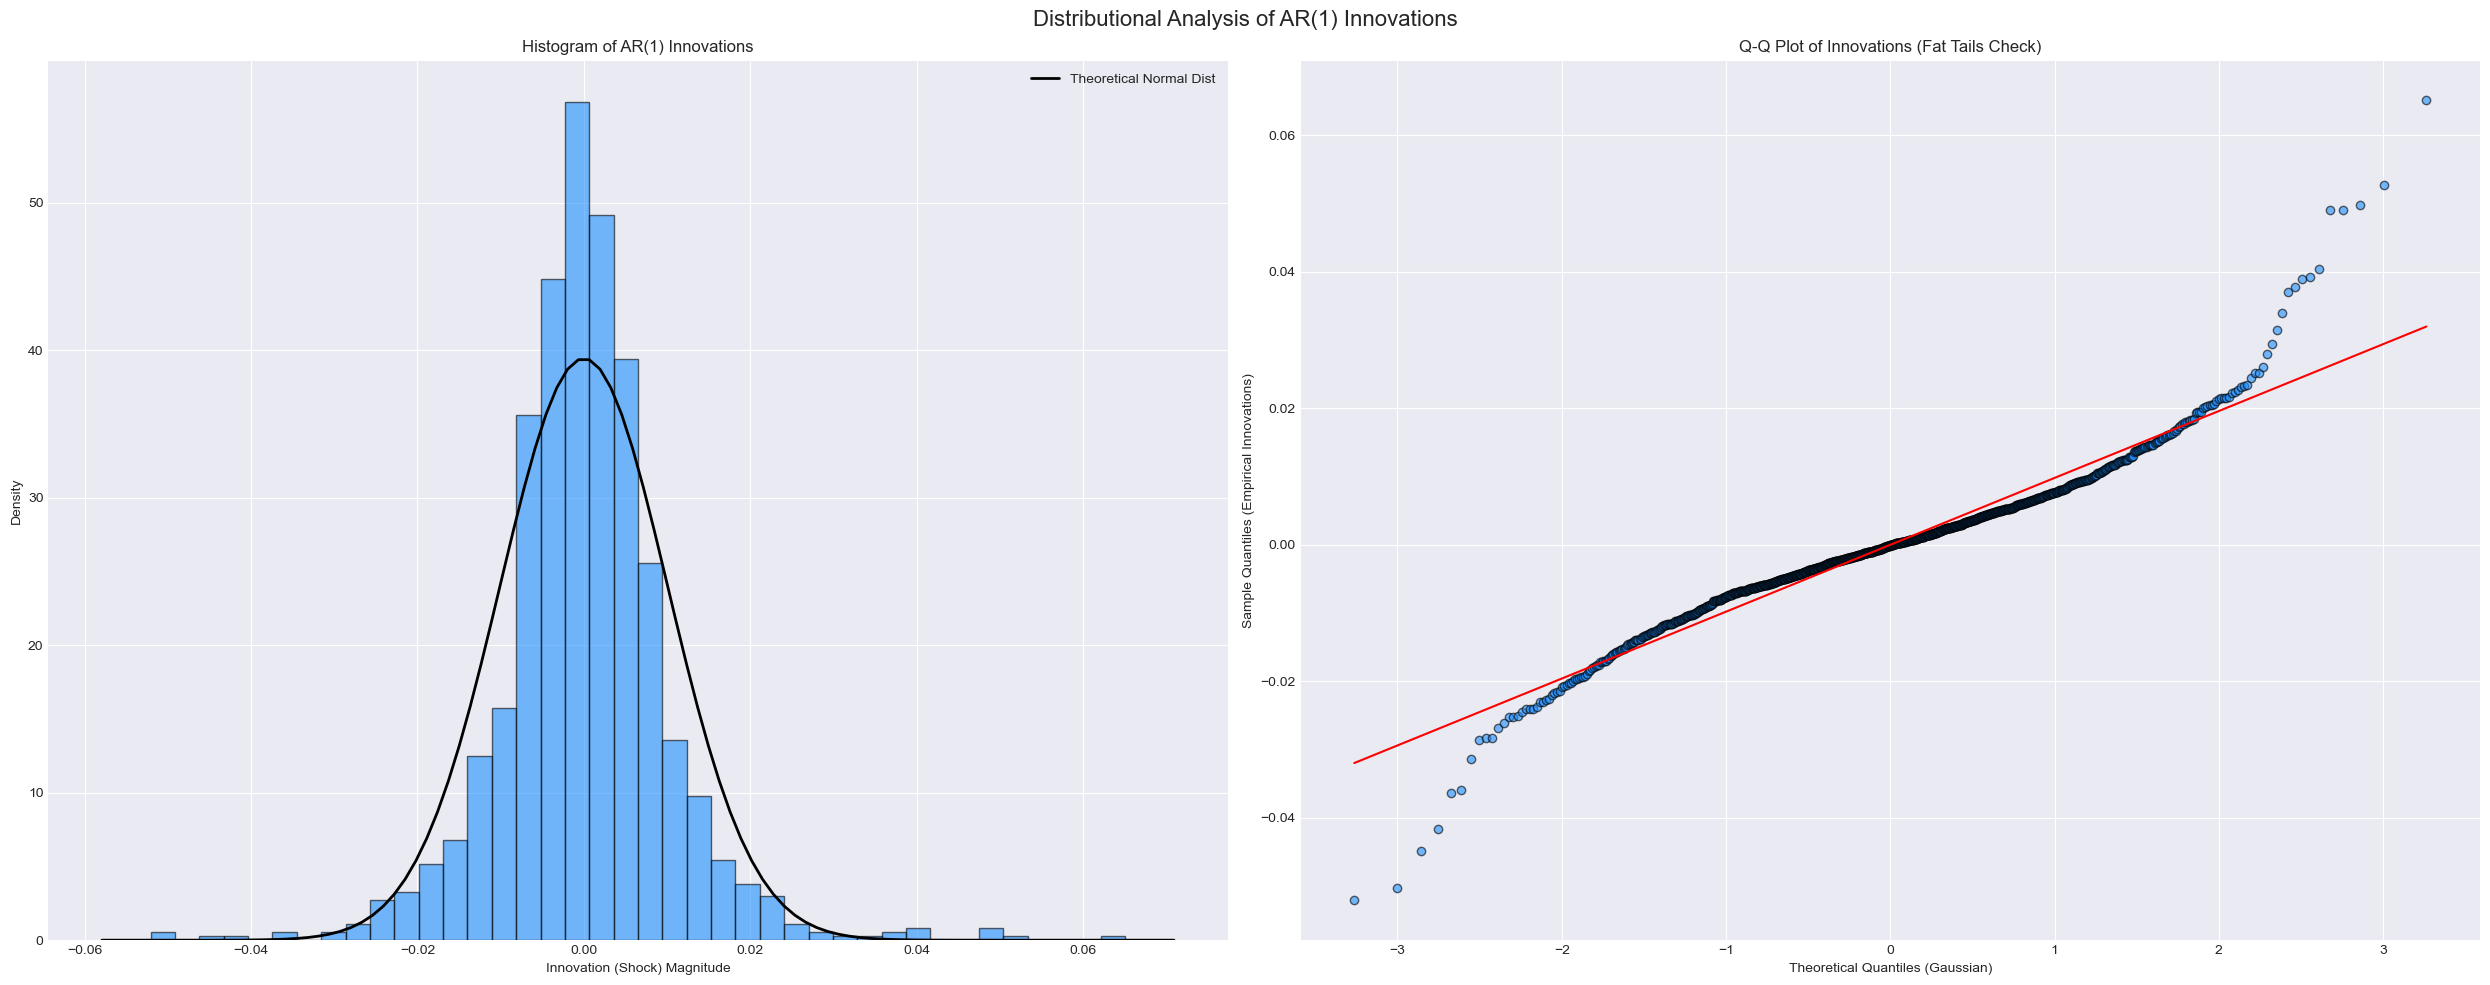

--- Innovation Distribution Metrics ---
Skewness:        0.3801 (0.0 is perfectly symmetrical)
Excess Kurtosis: 5.2405 (0.0 is perfectly normal)
Conclusion: Strong evidence of fat tails. Extreme market shocks occur more frequently than a Gaussian model predicts.
Implication: Static z-score entry thresholds will likely trigger prematurely during systemic stress events.


In [18]:
# ---------------------------------------------------------
# A. Distribution of AR(p) Innovations
# ---------------------------------------------------------
# Extract the innovations (shocks) from the fitted ARIMA model.
# We slice from [p:] to drop the first few days where the model is initializing 
# and the residuals might be artificially large.
innovations = fitted_model.resid[p:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10))

# Histogram of Innovations vs. Theoretical Normal
ax1.hist(innovations, bins=40, density=True, alpha=0.6, color='dodgerblue', edgecolor='black')

# Overlay theoretical normal distribution
mu_inv, std_inv = np.mean(innovations), np.std(innovations)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p_curve = stats.norm.pdf(x, mu_inv, std_inv)
ax1.plot(x, p_curve, 'k', linewidth=2, label='Theoretical Normal Dist')

ax1.set_title(f"Histogram of AR({p}) Innovations")
ax1.set_xlabel("Innovation (Shock) Magnitude")
ax1.set_ylabel("Density")
ax1.legend()

# 2. Q-Q Plot of Innovations
stats.probplot(innovations, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('dodgerblue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[0].set_alpha(0.6)
ax2.set_title("Q-Q Plot of Innovations (Fat Tails Check)")
ax2.set_xlabel("Theoretical Quantiles (Gaussian)")
ax2.set_ylabel("Sample Quantiles (Empirical Innovations)")

plt.suptitle(f"Distributional Analysis of AR({p}) Innovations", fontsize=16)
plt.tight_layout()
plt.show()

# Q-Q Plot
# A perfect normal distribution has an excess kurtosis of exactly 0.0.
# Any value > 0 indicates fat tails (Leptokurtic distribution).
excess_kurtosis = stats.kurtosis(innovations)
skewness = stats.skew(innovations)

print(f"--- Innovation Distribution Metrics ---")
print(f"Skewness:        {skewness:.4f} (0.0 is perfectly symmetrical)")
print(f"Excess Kurtosis: {excess_kurtosis:.4f} (0.0 is perfectly normal)")

if excess_kurtosis > 1.0:
    print("Conclusion: Strong evidence of fat tails. Extreme market shocks occur more frequently than a Gaussian model predicts.")
    print("Implication: Static z-score entry thresholds will likely trigger prematurely during systemic stress events.")

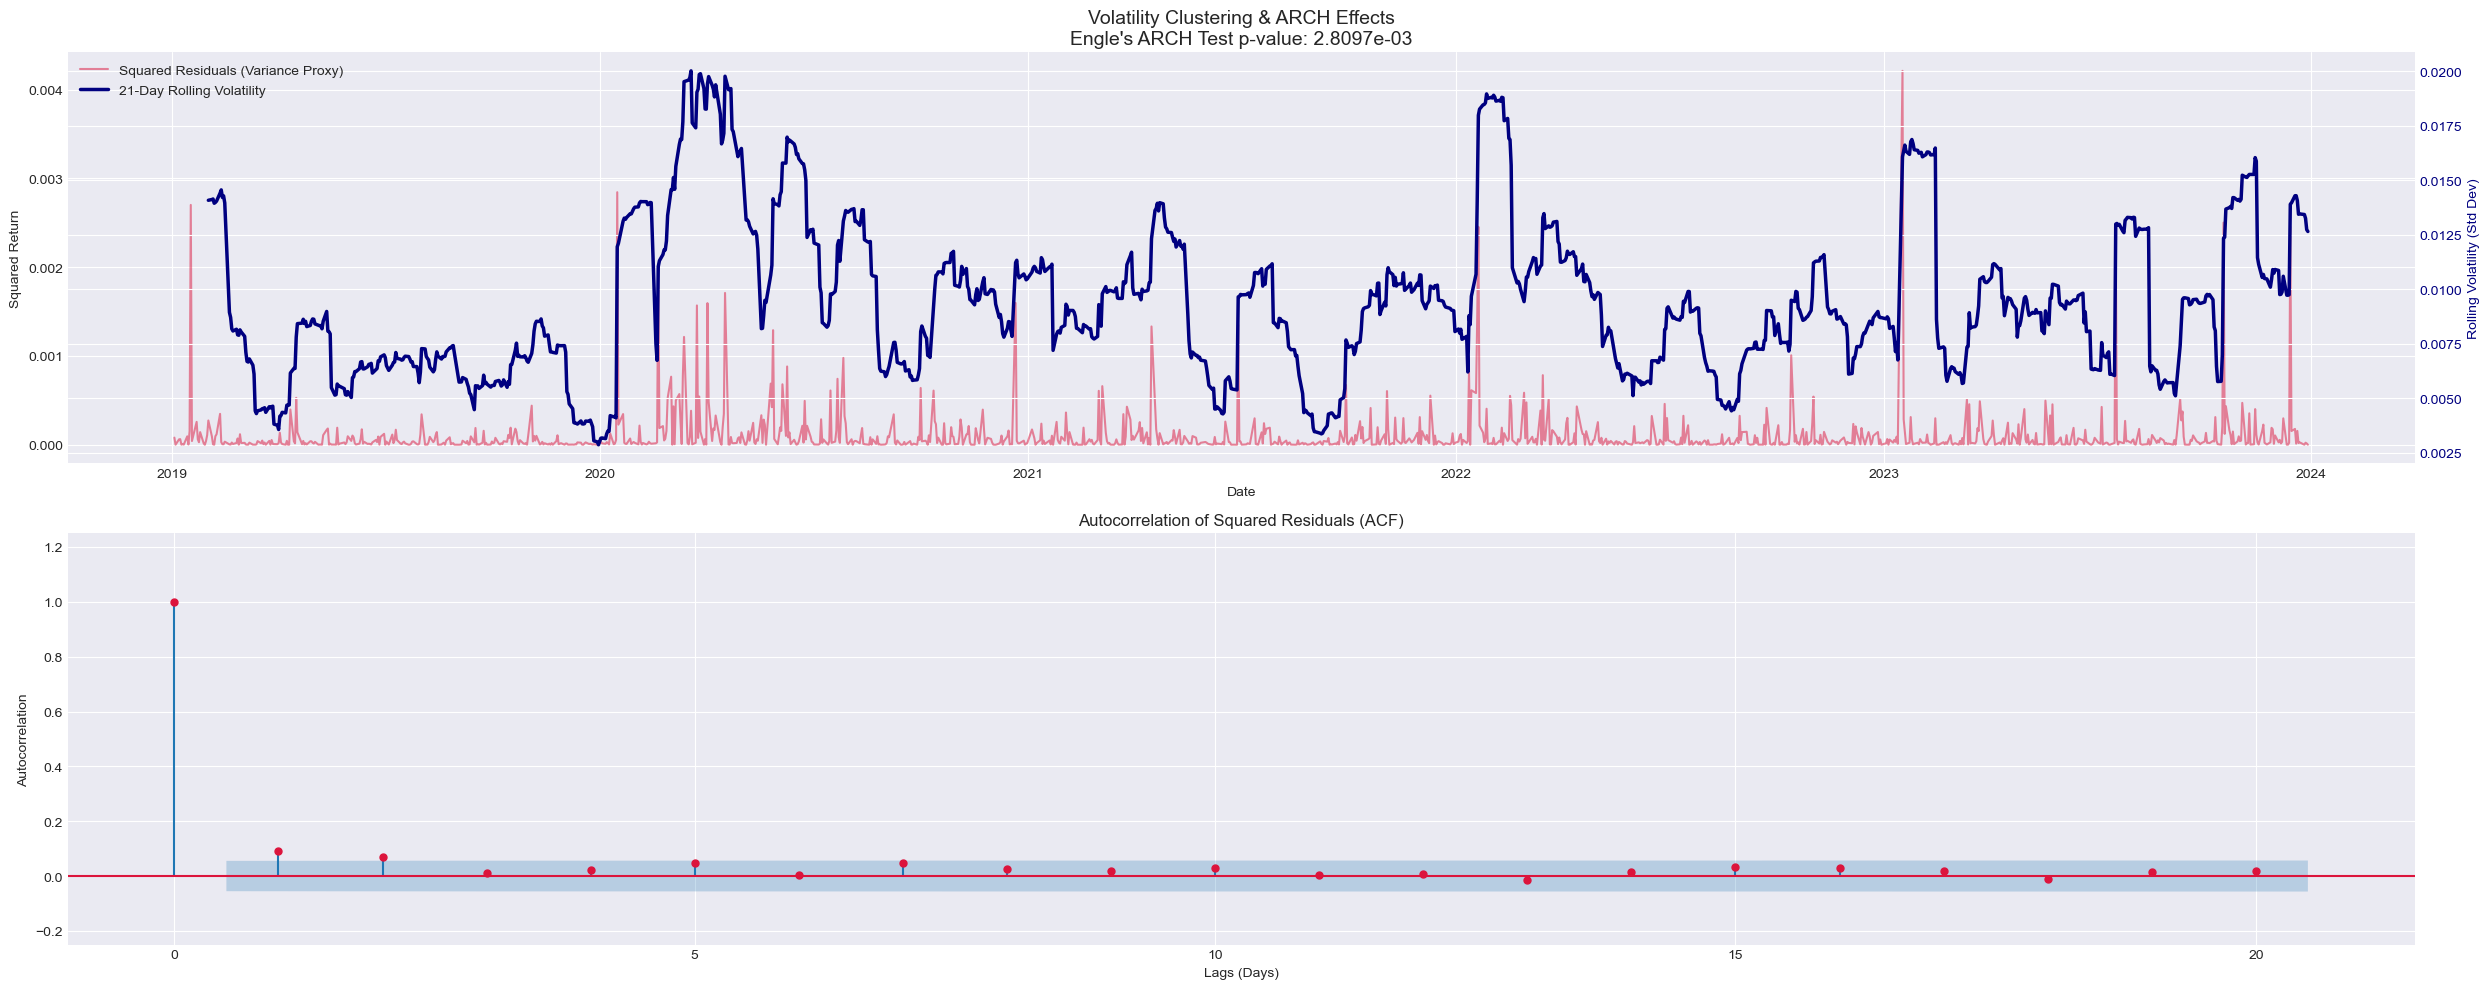

In [20]:
# ---------------------------------------------------------
# B. Heteroskedasticity (ARCH Effects)
# ---------------------------------------------------------
squared_residuals = stock_residual ** 2

# Calculate 21-day rolling volatility (Standard Deviation)
rolling_vol = stock_residual.rolling(window=21).std()

# Engle's Test for ARCH effects
# H0: No conditional heteroskedasticity
# Added .dropna() to ensure statsmodels doesn't fail on potential NaN values
arch_test_result = het_arch(stock_residual.dropna(), nlags=5)
arch_p_value = arch_test_result[1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(25, 10))

# Plot 1: Squared Residuals (Primary Y-Axis)
ax1.plot(squared_residuals.index, squared_residuals, color='crimson', alpha=0.5, label='Squared Residuals (Variance Proxy)')
ax1.set_title(f"Volatility Clustering & ARCH Effects\nEngle's ARCH Test p-value: {arch_p_value:.4e}", fontsize=14)
ax1.set_ylabel("Squared Return")
ax1.set_xlabel("Date")

# Plot 2: Rolling Volatility (Secondary Y-Axis)
ax1_vol = ax1.twinx()
ax1_vol.plot(rolling_vol.index, rolling_vol, color='navy', linewidth=2.5, label='21-Day Rolling Volatility')
ax1_vol.set_ylabel("Rolling Volatility (Std Dev)", color='navy')
ax1_vol.tick_params(axis='y', labelcolor='navy')

# Combine legends from both axes into one cohesive box
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_vol.get_legend_handles_labels()
ax1_vol.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Autocorrelation of squared residuals
plot_acf(squared_residuals.dropna(), ax=ax2, lags=20, alpha=0.05, color='crimson')
ax2.set_ylim(-0.25, 1.25)
ax2.set_title("Autocorrelation of Squared Residuals (ACF)")
ax2.set_xlabel("Lags (Days)")
ax2.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [29]:
print(arch_test_result)

(np.float64(18.111610727839448), np.float64(0.0028097293383646804), 3.6578781619299705, 0.0027310715998772944)
